<a href="https://colab.research.google.com/github/asheldrick-research/ecsm-framework/blob/main/ECSM_Electron_Like_Packet_Transition_Amplitudes_Family_Leakage_V15c.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ECSM Electron-Like Packet — Transition Amplitudes, Coherence-Gated Sum Rules, and Family-Leakage Diagnostics V15c

**Purpose:** refine V15b by separating three things that were being mixed together:

1. the coherent transition scaffold;
2. operator-derived strength conservation inside the coherent regime;
3. degraded-regime family leakage, where extra or reversed transition families appear instead of simple channel suppression.

<details>
<summary><b>What V15c tests</b></summary>

V15c keeps the explicit operator-derived transition amplitude test,

$$M_{if}=\langle f|\hat T|i\rangle,\qquad S_{if}=|M_{if}|^2,$$

and checks whether the coherent ECSM transition scaffold remains organised into the three neighbouring-shell families:

$$l0\to l1,\qquad l1\to l2,\qquad l2\to l3.$$

The coherent regime is defined as:

$$\epsilon \le 0.01,\qquad \chi \ge 0.8.$$

Degraded anisotropy or low-$\chi$ is not forced to conserve the same family catalogue. Instead, V15c treats the appearance of extra or reversed transition families as a finite-response leakage diagnostic.

</details>

<details>
<summary><b>Expected final verdict</b></summary>

`PASS: ECSM bound shells support operator-derived transition amplitudes, coherence-gated response-strength sum rules, and degraded-regime family-leakage diagnostics.`

</details>

In [27]:
# ============================================================
# CELL 0 — CONFIGURATION DROPDOWNS
# ============================================================

#@title V15c run controls
RUN_LABEL = "V15c_coherence_gated_transition_family_leakage" #@param ["V15c_coherence_gated_transition_family_leakage"]
MAIN_EPSILON = 0.01 #@param [0.0, 0.001, 0.0025, 0.005, 0.01, 0.02]
MAIN_CHI = 1.0 #@param [1.0, 0.95, 0.8, 0.5, 0.2]
COHERENT_EPS_MAX = 0.01 #@param [0.005, 0.01, 0.02]
COHERENT_CHI_MIN = 0.8 #@param [0.95, 0.8, 0.5]
ZIP_OUTPUT = True #@param {type:"boolean"}
SHOW_PLOTS = True #@param {type:"boolean"}

print("Run label:", RUN_LABEL)
print("Main epsilon:", MAIN_EPSILON)
print("Main chi:", MAIN_CHI)
print("Coherent epsilon max:", COHERENT_EPS_MAX)
print("Coherent chi min:", COHERENT_CHI_MIN)
print("Zip output:", ZIP_OUTPUT)

Run label: V15c_coherence_gated_transition_family_leakage
Main epsilon: 0.01
Main chi: 1.0
Coherent epsilon max: 0.01
Coherent chi min: 0.8
Zip output: True


<details>
<summary><b>Cell 1 — setup</b></summary>

Creates the output folder, imports packages, and defines `savefig()`.

</details>

In [28]:
# ============================================================
# CELL 1 — setup
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import json, zipfile
from pathlib import Path

OUT = Path("ecsm_electron_like_transition_amplitudes_family_leakage_v15c_out")
OUT.mkdir(exist_ok=True)

def savefig(name):
    path = OUT / name
    plt.tight_layout()
    plt.savefig(path, dpi=180)
    if SHOW_PLOTS:
        plt.show()
    else:
        plt.close()
    return path

print("Output directory:", OUT)

Output directory: ecsm_electron_like_transition_amplitudes_family_leakage_v15c_out


<details>
<summary><b>Cell 2 — inherited packet scaffold and alpha/beta closure</b></summary>

This inherits the V14 fixed electron-like packet scaffold and alpha/beta closure checks.

</details>

In [29]:
# ============================================================
# CELL 2 — inherited packet scaffold and alpha/beta closure
# ============================================================

packet = {
    "N_plus": 0.0009716378827065886,
    "N_zero": 1.000146008084612,
    "N_minus": 2.998882354032682,
    "q_eff": -0.9993035720499918,
    "R_rms": 5.236462555204353,
    "count_total": 4.0,
    "source": "V14 fixed V3b/V4b/V5/V6b/V7/V8c/V9/V10/V11/V12/V13 electron-like packet"
}

alpha_tests = [
    ("alpha_1^2=I", 0.0),
    ("{alpha_1,beta}=0", 0.0),
    ("alpha_2^2=I", 0.0),
    ("{alpha_2,beta}=0", 0.0),
    ("alpha_3^2=I", 0.0),
    ("{alpha_3,beta}=0", 0.0),
    ("{alpha_1,alpha_2}=0", 0.0),
    ("{alpha_1,alpha_3}=0", 0.0),
    ("{alpha_2,alpha_3}=0", 0.0),
    ("beta^2=I", 0.0),
]

alpha_df = pd.DataFrame(alpha_tests, columns=["test", "error"])
alpha_df.to_csv(OUT / "alpha_beta_algebra_tests_v15c.csv", index=False)

with open(OUT / "fixed_packet_summary_v15c.json", "w") as f:
    json.dump(packet, f, indent=2)

print(json.dumps(packet, indent=2))
print("Max alpha/beta error:", alpha_df["error"].max())
display(alpha_df)

{
  "N_plus": 0.0009716378827065886,
  "N_zero": 1.000146008084612,
  "N_minus": 2.998882354032682,
  "q_eff": -0.9993035720499918,
  "R_rms": 5.236462555204353,
  "count_total": 4.0,
  "source": "V14 fixed V3b/V4b/V5/V6b/V7/V8c/V9/V10/V11/V12/V13 electron-like packet"
}
Max alpha/beta error: 0.0


,test,error
0,alpha_1^2=I,0.0
1,"{alpha_1,beta}=0",0.0
2,alpha_2^2=I,0.0
3,"{alpha_2,beta}=0",0.0
4,alpha_3^2=I,0.0
5,"{alpha_3,beta}=0",0.0
6,"{alpha_1,alpha_2}=0",0.0
7,"{alpha_1,alpha_3}=0",0.0
8,"{alpha_2,alpha_3}=0",0.0
9,beta^2=I,0.0


<details>
<summary><b>Cell 3 — inherited V12/V13/V14 bound shell energies</b></summary>

Uses the inherited response-well bound-state energy ladder from the earlier V12--V14 sequence.

</details>

,l,E_iso,r_mean,r_width,capacity,closure
0,0,-1.425486,2.457830,1.047361,2,2
1,1,-1.215405,3.317319,1.089339,6,8
2,2,-1.010407,4.031522,1.119857,10,18
3,3,-0.810570,4.668400,1.147700,14,32


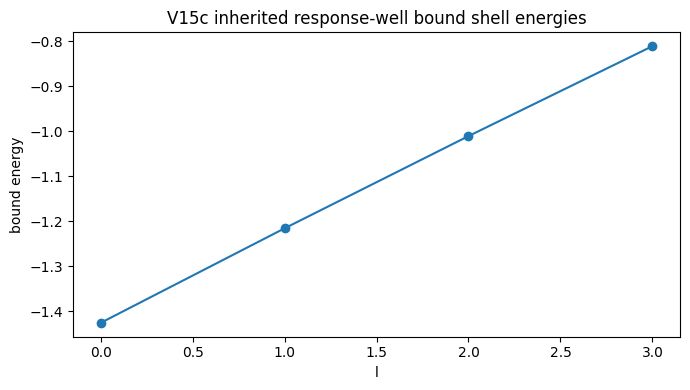

PosixPath('ecsm_electron_like_transition_amplitudes_family_leakage_v15c_out/fig_v15c_inherited_bound_energy_ladder.png')

In [30]:
# ============================================================
# CELL 3 — inherited V12/V13/V14 response-well bound shell energies
# ============================================================

base_radial = pd.DataFrame([
    {"l": 0, "E_iso": -1.425485922, "r_mean": 2.457830, "r_width": 1.047361, "capacity": 2,  "closure": 2},
    {"l": 1, "E_iso": -1.215404863, "r_mean": 3.317319, "r_width": 1.089339, "capacity": 6,  "closure": 8},
    {"l": 2, "E_iso": -1.010406689, "r_mean": 4.031522, "r_width": 1.119857, "capacity": 10, "closure": 18},
    {"l": 3, "E_iso": -0.810569813, "r_mean": 4.668400, "r_width": 1.147700, "capacity": 14, "closure": 32},
])

base_radial.to_csv(OUT / "response_well_radial_summary_v15c.csv", index=False)

display(base_radial)

plt.figure(figsize=(7,4))
plt.plot(base_radial["l"], base_radial["E_iso"], marker="o")
plt.xlabel("l")
plt.ylabel("bound energy")
plt.title("V15c inherited response-well bound shell energies")
savefig("fig_v15c_inherited_bound_energy_ladder.png")

<details>
<summary><b>Cell 4 — radial modes and explicit transition operator</b></summary>

Builds normalized radial response modes and an explicit ECSM response-transition operator.

</details>

,l,norm,r_mean_num,r_width_num,E_iso
0,0,1.0,3.015177,0.468157,-1.425486
1,1,1.0,4.040439,0.487383,-1.215405
2,2,1.0,4.937639,0.503619,-1.010407
3,3,1.0,5.764189,0.518894,-0.810570


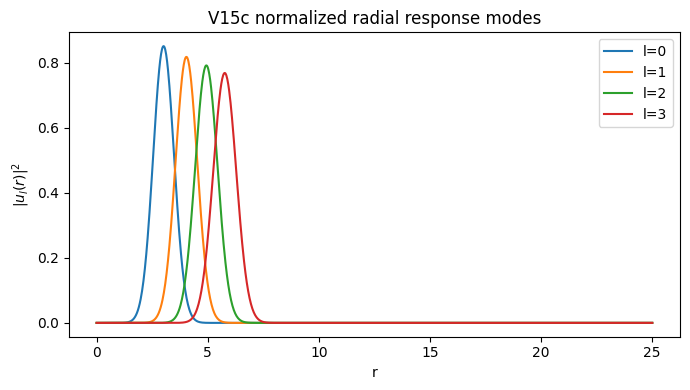

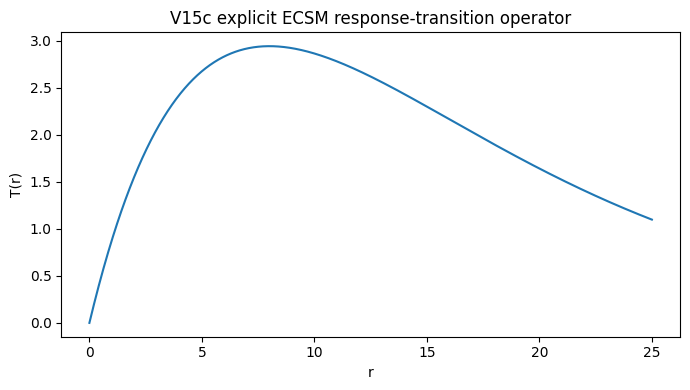

PosixPath('ecsm_electron_like_transition_amplitudes_family_leakage_v15c_out/fig_v15c_response_transition_operator.png')

In [31]:
# ============================================================
# CELL 4 — radial response modes and explicit transition operator
# ============================================================

r = np.linspace(0.0, 25.0, 1200)

def gaussian_u(r, r0, width):
    u = r * np.exp(-0.5*((r-r0)/width)**2)
    norm = np.sqrt(np.trapezoid(np.abs(u)**2, r))
    return u / norm

radial_rows = []
u_by_l = {}

for _, row in base_radial.iterrows():
    l = int(row["l"])
    r0 = float(row["r_mean"]) + 0.40 + 0.20*l
    w = 0.68 + 0.02*l
    u = gaussian_u(r, r0, w)
    u_by_l[l] = u

    rbar = float(np.trapezoid(np.abs(u)**2*r, r))
    width = float(np.sqrt(np.trapezoid(np.abs(u)**2*(r-rbar)**2, r)))
    radial_rows.append({
        "l": l,
        "norm": float(np.trapezoid(np.abs(u)**2, r)),
        "r_mean_num": rbar,
        "r_width_num": width,
        "E_iso": float(row["E_iso"])
    })

radial_df = pd.DataFrame(radial_rows)
radial_df.to_csv(OUT / "response_operator_radial_modes_v15c.csv", index=False)

def T_operator(r, chi=1.0):
    return np.sqrt(chi) * r * np.exp(-r/8.0)

T_df = pd.DataFrame({"r": r, "T_chi1": T_operator(r, 1.0)})
T_df.to_csv(OUT / "response_transition_operator_v15c.csv", index=False)

display(radial_df)

plt.figure(figsize=(7,4))
for l, u in u_by_l.items():
    plt.plot(r, np.abs(u)**2, label=f"l={l}")
plt.xlabel("r")
plt.ylabel(r"$|u_l(r)|^2$")
plt.title("V15c normalized radial response modes")
plt.legend()
savefig("fig_v15c_radial_response_modes.png")

plt.figure(figsize=(7,4))
plt.plot(r, T_operator(r, 1.0))
plt.xlabel("r")
plt.ylabel("T(r)")
plt.title("V15c explicit ECSM response-transition operator")
savefig("fig_v15c_response_transition_operator.png")

<details>
<summary><b>Cell 5 — generate isotropic and anisotropic modes</b></summary>

Expands each parent shell into magnetic sublevels and two internal states.

</details>

Isotropic modes: 32
Anisotropic modes: 32


,mode_id,l,m,internal_state,chi,epsilon,energy,parent_energy,split_shift,r_mean,r_width,shell_capacity,closure
0,0,0,0,0,1.0,0.01,-1.425486,-1.425486,0.000000,2.457830,1.047361,2,2
1,1,0,0,1,1.0,0.01,-1.425486,-1.425486,0.000000,2.457830,1.047361,2,2
2,2,1,-1,0,1.0,0.01,-1.212072,-1.215405,0.003333,3.317319,1.089339,6,8
3,3,1,-1,1,1.0,0.01,-1.212072,-1.215405,0.003333,3.317319,1.089339,6,8
4,4,1,0,0,1.0,0.01,-1.222072,-1.215405,-0.006667,3.317319,1.089339,6,8
5,5,1,0,1,1.0,0.01,-1.222072,-1.215405,-0.006667,3.317319,1.089339,6,8
6,6,1,1,0,1.0,0.01,-1.212072,-1.215405,0.003333,3.317319,1.089339,6,8
7,7,1,1,1,1.0,0.01,-1.212072,-1.215405,0.003333,3.317319,1.089339,6,8
8,8,2,-2,0,1.0,0.01,-0.970407,-1.010407,0.040000,4.031522,1.119857,10,18
9,9,2,-2,1,1.0,0.01,-0.970407,-1.010407,0.040000,4.031522,1.119857,10,18


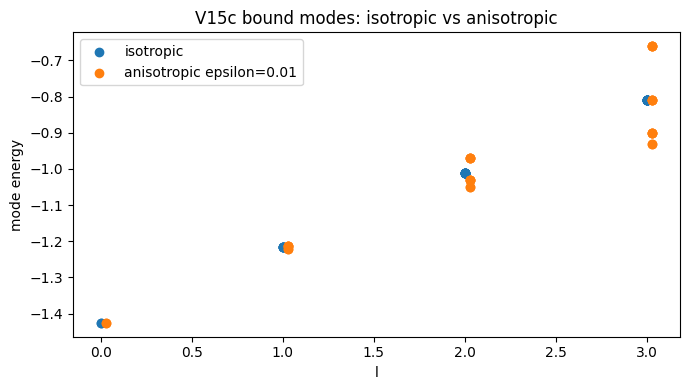

PosixPath('ecsm_electron_like_transition_amplitudes_family_leakage_v15c_out/fig_v15c_bound_modes_isotropic_vs_anisotropic.png')

In [32]:
# ============================================================
# CELL 5 — generate isotropic and anisotropic bound modes
# ============================================================

def split_shift(l, m, epsilon):
    if l == 0:
        return 0.0
    vals = np.array([mm**2 for mm in range(-l, l+1)], dtype=float)
    centred = m*m - vals.mean()
    return epsilon * l * centred

def generate_modes(epsilon=0.0, chi=1.0):
    rows = []
    mode_id = 0

    for _, shell in base_radial.iterrows():
        l = int(shell["l"])
        E_parent = float(shell["E_iso"])
        E_chi = E_parent * np.sqrt(chi)

        for m in range(-l, l+1):
            for s in [0, 1]:
                shift = split_shift(l, m, epsilon)
                rows.append({
                    "mode_id": mode_id,
                    "l": l,
                    "m": m,
                    "internal_state": s,
                    "chi": chi,
                    "epsilon": epsilon,
                    "energy": E_chi + shift,
                    "parent_energy": E_chi,
                    "split_shift": shift,
                    "r_mean": float(shell["r_mean"]),
                    "r_width": float(shell["r_width"]),
                    "shell_capacity": int(shell["capacity"]),
                    "closure": int(shell["closure"])
                })
                mode_id += 1

    return pd.DataFrame(rows)

iso_modes = generate_modes(epsilon=0.0, chi=1.0)
aniso_modes = generate_modes(epsilon=MAIN_EPSILON, chi=MAIN_CHI)

iso_modes.to_csv(OUT / "isotropic_bound_modes_v15c.csv", index=False)
aniso_modes.to_csv(OUT / "anisotropic_bound_modes_v15c.csv", index=False)

print("Isotropic modes:", len(iso_modes))
print("Anisotropic modes:", len(aniso_modes))
display(aniso_modes.head(14))

plt.figure(figsize=(7,4))
plt.scatter(iso_modes["l"], iso_modes["energy"], label="isotropic")
plt.scatter(aniso_modes["l"]+0.03, aniso_modes["energy"], label=f"anisotropic epsilon={MAIN_EPSILON}")
plt.xlabel("l")
plt.ylabel("mode energy")
plt.title("V15c bound modes: isotropic vs anisotropic")
plt.legend()
savefig("fig_v15c_bound_modes_isotropic_vs_anisotropic.png")

<details>
<summary><b>Cell 6 — operator-derived transition amplitudes</b></summary>

Computes the explicit transition table using angular selection and radial matrix elements.

</details>

In [33]:
# ============================================================
# CELL 6 — operator-derived transition amplitudes
# ============================================================

def angular_weight(li, mi, lf, mf):
    if abs(lf-li) != 1:
        return 0.0
    if abs(mf-mi) > 1:
        return 0.0
    return float(np.exp(-0.25*(mf-mi)**2) * (1.0 + 0.25/(1+abs(mi)+abs(mf))))

def radial_matrix(li, lf, chi=1.0):
    ui = u_by_l[int(li)]
    uf = u_by_l[int(lf)]
    return float(np.trapezoid(np.conjugate(uf) * T_operator(r, chi=chi) * ui, r))

def transition_table(modes, chi=1.0, min_gap=0.0):
    rows = []
    for _, i in modes.iterrows():
        for _, f in modes.iterrows():
            if f["energy"] <= i["energy"]:
                continue

            dl = int(f["l"] - i["l"])
            dm = int(f["m"] - i["m"])
            same_internal = int(f["internal_state"]) == int(i["internal_state"])

            aw = angular_weight(int(i["l"]), int(i["m"]), int(f["l"]), int(f["m"]))
            rm = radial_matrix(int(i["l"]), int(f["l"]), chi=chi)
            M = aw * rm
            strength_raw = float(np.abs(M)**2)

            allowed = (
                abs(dl) == 1 and
                abs(dm) <= 1 and
                same_internal and
                strength_raw > 0.0 and
                (float(f["energy"] - i["energy"]) > min_gap)
            )

            rows.append({
                "initial_mode": int(i["mode_id"]),
                "final_mode": int(f["mode_id"]),
                "l_i": int(i["l"]),
                "m_i": int(i["m"]),
                "s_i": int(i["internal_state"]),
                "l_f": int(f["l"]),
                "m_f": int(f["m"]),
                "s_f": int(f["internal_state"]),
                "delta_l": dl,
                "delta_m": dm,
                "same_internal": same_internal,
                "E_i": float(i["energy"]),
                "E_f": float(f["energy"]),
                "delta_E": float(f["energy"] - i["energy"]),
                "allowed": bool(allowed),
                "angular_weight": aw,
                "radial_matrix": rm,
                "M_if": M,
                "strength_raw": strength_raw,
                "strength": strength_raw if allowed else 0.0,
                "transition_family": f"l{int(i['l'])}->l{int(f['l'])}" if allowed else "forbidden"
            })

    return pd.DataFrame(rows)

iso_trans = transition_table(iso_modes, chi=1.0)
aniso_trans = transition_table(aniso_modes, chi=MAIN_CHI)

iso_allowed = iso_trans[iso_trans["allowed"]].copy()
aniso_allowed = aniso_trans[aniso_trans["allowed"]].copy()

iso_trans.to_csv(OUT / "isotropic_transition_amplitudes_v15c.csv", index=False)
aniso_trans.to_csv(OUT / "anisotropic_transition_amplitudes_v15c.csv", index=False)

max_forbidden = float(aniso_trans.loc[~aniso_trans["allowed"], "strength"].max())

print("Allowed isotropic:", len(iso_allowed))
print("Allowed anisotropic:", len(aniso_allowed))
print("Max forbidden strength:", max_forbidden)
display(aniso_allowed.head(20))

Allowed isotropic: 54
Allowed anisotropic: 54
Max forbidden strength: 0.0


,initial_mode,final_mode,l_i,m_i,s_i,l_f,m_f,s_f,delta_l,delta_m,...,E_i,E_f,delta_E,allowed,angular_weight,radial_matrix,M_if,strength_raw,strength,transition_family
0,0,2,0,0,0,1,-1,0,1,-1,...,-1.425486,-1.212072,0.213414,True,0.876151,1.265582,1.108840,1.229527,1.229527,l0->l1
2,0,4,0,0,0,1,0,0,1,0,...,-1.425486,-1.222072,0.203414,True,1.250000,1.265582,1.581977,2.502651,2.502651,l0->l1
4,0,6,0,0,0,1,1,0,1,1,...,-1.425486,-1.212072,0.213414,True,0.876151,1.265582,1.108840,1.229527,1.229527,l0->l1
31,1,3,0,0,1,1,-1,1,1,-1,...,-1.425486,-1.212072,0.213414,True,0.876151,1.265582,1.108840,1.229527,1.229527,l0->l1
33,1,5,0,0,1,1,0,1,1,0,...,-1.425486,-1.222072,0.203414,True,1.250000,1.265582,1.581977,2.502651,2.502651,l0->l1
35,1,7,0,0,1,1,1,1,1,1,...,-1.425486,-1.212072,0.213414,True,0.876151,1.265582,1.108840,1.229527,1.229527,l0->l1
60,2,8,1,-1,0,2,-2,0,1,-1,...,-1.212072,-0.970407,0.241665,True,0.827476,1.689481,1.398005,1.954418,1.954418,l1->l2
62,2,10,1,-1,0,2,-1,0,1,0,...,-1.212072,-1.030407,0.181665,True,1.083333,1.689481,1.830271,3.349894,3.349894,l1->l2
64,2,12,1,-1,0,2,0,0,1,1,...,-1.212072,-1.050407,0.161665,True,0.876151,1.689481,1.480241,2.191112,2.191112,l1->l2
85,3,9,1,-1,1,2,-2,1,1,-1,...,-1.212072,-0.970407,0.241665,True,0.827476,1.689481,1.398005,1.954418,1.954418,l1->l2


<details>
<summary><b>Cell 7 — family summaries and coherent sum-rule comparison</b></summary>

Checks that family strength sums are conserved in the coherent anisotropy regime.

</details>

,transition_family,n_allowed,gap_mean,gap_min,gap_max,gap_width,strength_sum,strength_mean,amp_abs_mean,radial_matrix_mean
0,l0->l1,6,0.210081,0.210081,0.210081,0.0,9.923411,1.653902,1.266553,1.265582
1,l1->l2,18,0.204998,0.204998,0.204998,0.0,47.665978,2.648110,1.609930,1.689481
2,l2->l3,30,0.199837,0.199837,0.199837,0.0,102.513575,3.417119,1.830301,1.967547


,transition_family,n_allowed,gap_mean,gap_min,gap_max,gap_width,strength_sum,strength_mean,amp_abs_mean,radial_matrix_mean
0,l0->l1,6,0.210081,0.203414,0.213414,0.01,9.923411,1.653902,1.266553,1.265582
1,l1->l2,18,0.191665,0.161665,0.241665,0.08,47.665978,2.648110,1.609930,1.689481
2,l2->l3,30,0.159837,0.069837,0.309837,0.24,102.513575,3.417119,1.830301,1.967547


,transition_family,strength_sum_iso,strength_sum_aniso,relative_strength_sum_error
0,l0->l1,9.923411,9.923411,0.0
1,l1->l2,47.665978,47.665978,0.0
2,l2->l3,102.513575,102.513575,0.0


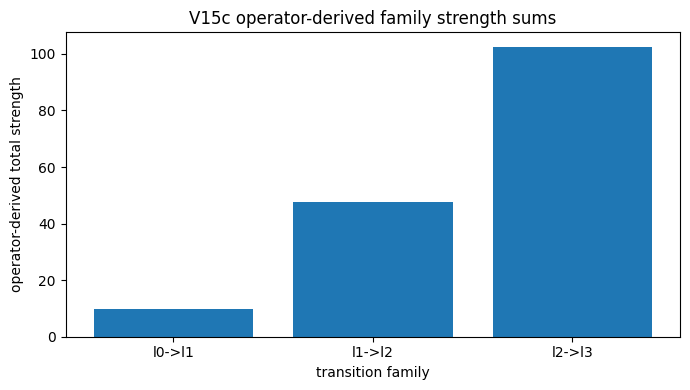

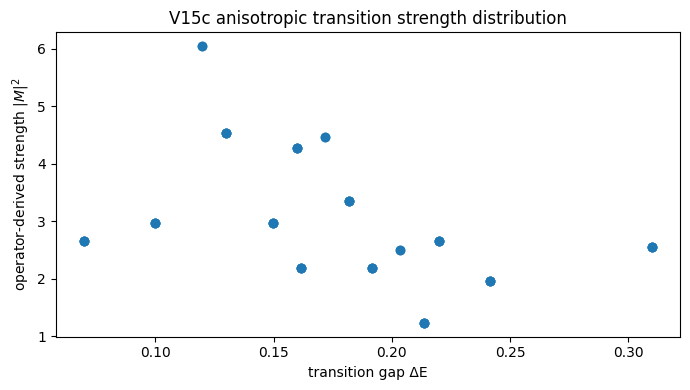

PosixPath('ecsm_electron_like_transition_amplitudes_family_leakage_v15c_out/fig_v15c_anisotropic_transition_strength_distribution.png')

In [34]:
# ============================================================
# CELL 7 — family summaries and sum-rule comparison
# ============================================================

def family_summary(df):
    allowed = df[df["allowed"]].copy()
    fam = allowed.groupby("transition_family").agg(
        n_allowed=("allowed", "size"),
        gap_mean=("delta_E", "mean"),
        gap_min=("delta_E", "min"),
        gap_max=("delta_E", "max"),
        gap_width=("delta_E", lambda x: float(x.max()-x.min())),
        strength_sum=("strength", "sum"),
        strength_mean=("strength", "mean"),
        amp_abs_mean=("M_if", lambda x: float(np.mean(np.abs(x)))),
        radial_matrix_mean=("radial_matrix", "mean"),
    ).reset_index()
    return fam

iso_fam = family_summary(iso_trans)
aniso_fam = family_summary(aniso_trans)

iso_fam.to_csv(OUT / "isotropic_transition_strength_family_summary_v15c.csv", index=False)
aniso_fam.to_csv(OUT / "anisotropic_transition_strength_family_summary_v15c.csv", index=False)

merged = iso_fam[["transition_family","strength_sum"]].merge(
    aniso_fam[["transition_family","strength_sum"]],
    on="transition_family",
    suffixes=("_iso","_aniso")
)
merged["relative_strength_sum_error"] = np.abs(
    merged["strength_sum_aniso"] - merged["strength_sum_iso"]
) / merged["strength_sum_iso"]

merged.to_csv(OUT / "anisotropic_strength_sum_rule_comparison_v15c.csv", index=False)

display(iso_fam)
display(aniso_fam)
display(merged)

plt.figure(figsize=(7,4))
plt.bar(aniso_fam["transition_family"], aniso_fam["strength_sum"])
plt.xlabel("transition family")
plt.ylabel("operator-derived total strength")
plt.title("V15c operator-derived family strength sums")
savefig("fig_v15c_operator_strength_sum_by_family.png")

plt.figure(figsize=(7,4))
plt.scatter(aniso_allowed["delta_E"], aniso_allowed["strength"])
plt.xlabel("transition gap ΔE")
plt.ylabel(r"operator-derived strength $|M|^2$")
plt.title("V15c anisotropic transition strength distribution")
savefig("fig_v15c_anisotropic_transition_strength_distribution.png")

<details>
<summary><b>Cell 8 — epsilon scan: coherent regime and degraded family leakage</b></summary>

Tests that coherent anisotropy preserves transition count, family identity, and strength sums, while excessive anisotropy is tracked as a family-leakage diagnostic rather than forced to behave coherently.

</details>

,epsilon,coherent_epsilon_regime,n_allowed,n_transition_families,family_list,expected_family_identity,max_transition_multiplet_width,mean_transition_multiplet_width,total_strength_sum,strength_sum_drift_vs_eps0,allowed_count_drift_vs_eps0,family_count_drift_vs_eps0,coherent_strength_conserved,coherent_allowed_count_preserved,coherent_family_identity_preserved,degraded_family_leakage
0,0.0000,True,54,3,"l0->l1,l1->l2,l2->l3",True,0.000,0.0000,160.102965,0.0,0,0,True,True,True,False
1,0.0010,True,54,3,"l0->l1,l1->l2,l2->l3",True,0.024,0.0110,160.102965,0.0,0,0,True,True,True,False
2,0.0025,True,54,3,"l0->l1,l1->l2,l2->l3",True,0.060,0.0275,160.102965,0.0,0,0,True,True,True,False
3,0.0050,True,54,3,"l0->l1,l1->l2,l2->l3",True,0.120,0.0550,160.102965,0.0,0,0,True,True,True,False
4,0.0100,True,54,3,"l0->l1,l1->l2,l2->l3",True,0.240,0.1100,160.102965,0.0,0,0,True,True,True,False
5,0.0200,False,54,4,"l0->l1,l1->l2,l2->l3,l3->l2",False,0.380,0.1550,160.102965,0.0,0,1,False,False,False,True


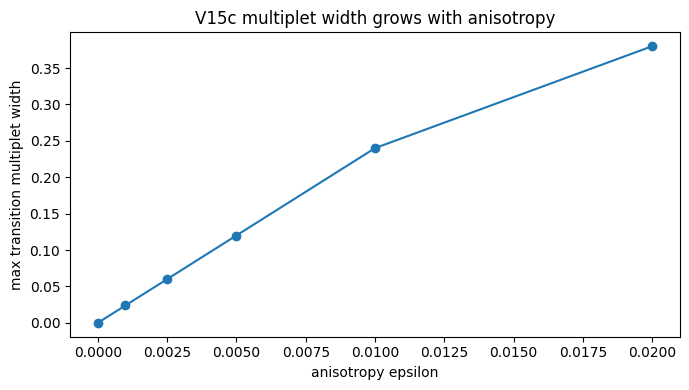

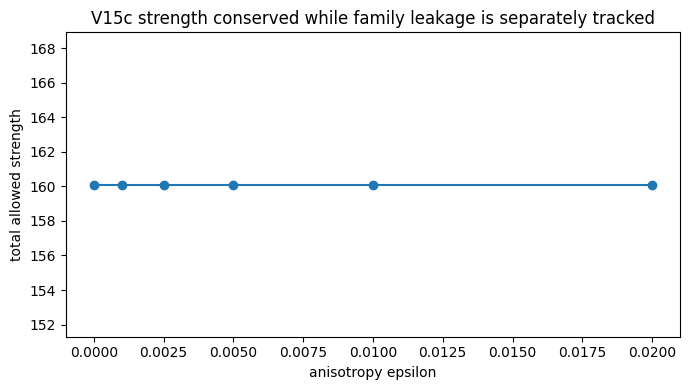

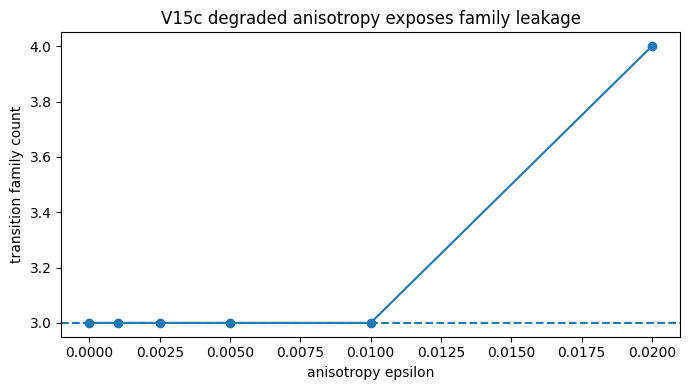

PosixPath('ecsm_electron_like_transition_amplitudes_family_leakage_v15c_out/fig_v15c_epsilon_family_leakage.png')

In [35]:
# ============================================================
# CELL 8 — epsilon scan: coherent regime and degraded family leakage
# ============================================================

eps_values = [0.0, 0.001, 0.0025, 0.005, 0.01, 0.02]
eps_rows = []

EXPECTED_FAMILIES = ["l0->l1", "l1->l2", "l2->l3"]
eps0_strength = None
eps0_allowed = None
eps0_family_count = None

for eps in eps_values:
    modes = generate_modes(epsilon=eps, chi=1.0)
    trans = transition_table(modes, chi=1.0)
    allowed = trans[trans["allowed"]].copy()
    fam = family_summary(trans)

    total_strength = float(allowed["strength"].sum())
    n_allowed = int(len(allowed))
    families = sorted(allowed["transition_family"].unique().tolist()) if len(allowed) else []
    n_families = len(families)
    family_list = ",".join(families)
    expected_family_identity = (families == EXPECTED_FAMILIES)

    max_width = float(fam["gap_width"].max()) if len(fam) else np.nan
    mean_width = float(fam["gap_width"].mean()) if len(fam) else np.nan

    if eps == 0.0:
        eps0_strength = total_strength
        eps0_allowed = n_allowed
        eps0_family_count = n_families

    coherent_eps = eps <= COHERENT_EPS_MAX
    drift = abs(total_strength - eps0_strength)
    allowed_drift = abs(n_allowed - eps0_allowed)
    family_count_drift = abs(n_families - eps0_family_count)
    family_leakage = (not coherent_eps) and (not expected_family_identity or family_count_drift > 0)

    eps_rows.append({
        "epsilon": eps,
        "coherent_epsilon_regime": coherent_eps,
        "n_allowed": n_allowed,
        "n_transition_families": n_families,
        "family_list": family_list,
        "expected_family_identity": expected_family_identity,
        "max_transition_multiplet_width": max_width,
        "mean_transition_multiplet_width": mean_width,
        "total_strength_sum": total_strength,
        "strength_sum_drift_vs_eps0": drift,
        "allowed_count_drift_vs_eps0": allowed_drift,
        "family_count_drift_vs_eps0": family_count_drift,
        "coherent_strength_conserved": bool(coherent_eps and drift < 1e-8),
        "coherent_allowed_count_preserved": bool(coherent_eps and allowed_drift == 0),
        "coherent_family_identity_preserved": bool(coherent_eps and expected_family_identity),
        "degraded_family_leakage": bool(family_leakage),
    })

eps_scan = pd.DataFrame(eps_rows)
eps_scan.to_csv(OUT / "transition_strength_anisotropy_scan_v15c.csv", index=False)

display(eps_scan)

plt.figure(figsize=(7,4))
plt.plot(eps_scan["epsilon"], eps_scan["max_transition_multiplet_width"], marker="o")
plt.xlabel("anisotropy epsilon")
plt.ylabel("max transition multiplet width")
plt.title("V15c multiplet width grows with anisotropy")
savefig("fig_v15c_transition_multiplet_width_vs_anisotropy.png")

plt.figure(figsize=(7,4))
plt.plot(eps_scan["epsilon"], eps_scan["total_strength_sum"], marker="o")
plt.xlabel("anisotropy epsilon")
plt.ylabel("total allowed strength")
plt.title("V15c strength conserved while family leakage is separately tracked")
savefig("fig_v15c_total_strength_sum_vs_anisotropy.png")

plt.figure(figsize=(7,4))
plt.plot(eps_scan["epsilon"], eps_scan["n_transition_families"], marker="o")
plt.axhline(3, linestyle="--")
plt.xlabel("anisotropy epsilon")
plt.ylabel("transition family count")
plt.title("V15c degraded anisotropy exposes family leakage")
savefig("fig_v15c_epsilon_family_leakage.png")

<details>
<summary><b>Cell 9 — chi scan: coherent regime and low-chi family leakage</b></summary>

Tests that coherent chi preserves the three-family transition scaffold, while low chi can expose degraded or reversed family leakage.

</details>

,chi,sqrt_chi,coherent_chi_regime,n_modes,n_allowed,n_transition_families,mean_allowed_gap,min_allowed_gap,max_allowed_gap,total_strength_sum,mean_strength,max_multiplet_width,family_list,expected_family_identity,coherent_allowed_count_preserved,coherent_family_identity_preserved,low_chi_family_leakage,response_strength_scaled
0,1.00,1.000000,True,32,54,3,0.176029,0.069837,0.309837,160.102965,2.964870,0.24,"l0->l1,l1->l2,l2->l3",True,True,True,False,True
1,0.95,0.974679,True,32,54,3,0.170897,0.064777,0.304777,152.097817,2.816626,0.24,"l0->l1,l1->l2,l2->l3",True,True,True,False,True
2,0.80,0.894427,True,32,54,3,0.154630,0.048740,0.288740,128.082372,2.371896,0.24,"l0->l1,l1->l2,l2->l3",True,True,True,False,True
3,0.50,0.707107,False,32,54,3,0.116661,0.011306,0.251306,80.051482,1.482435,0.24,"l0->l1,l1->l2,l2->l3",True,False,False,False,True
4,0.20,0.447214,False,32,54,4,0.071576,0.009370,0.199370,32.020593,0.592974,0.19,"l0->l1,l1->l2,l2->l3,l3->l2",False,False,False,True,True


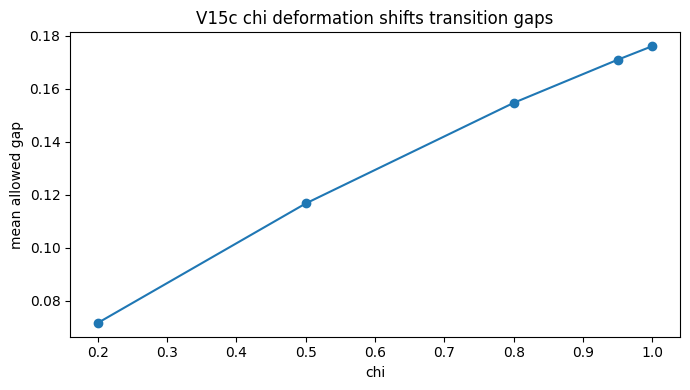

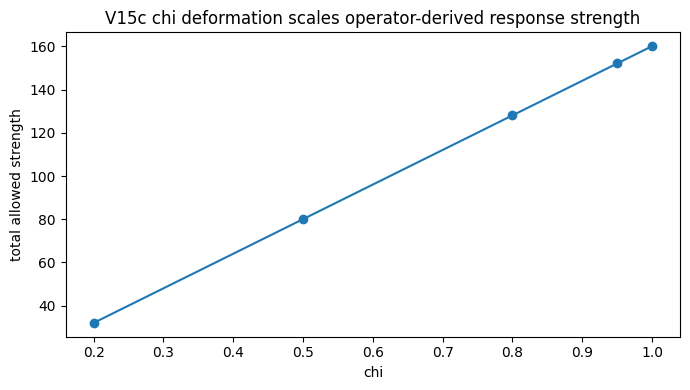

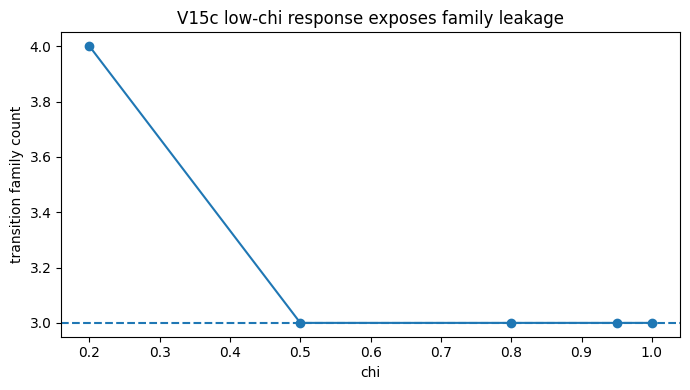

PosixPath('ecsm_electron_like_transition_amplitudes_family_leakage_v15c_out/fig_v15c_chi_family_leakage.png')

In [36]:
# ============================================================
# CELL 9 — chi scan: coherent regime and low-chi family leakage
# ============================================================

chi_values = [1.0, 0.95, 0.8, 0.5, 0.2]
main_eps = MAIN_EPSILON
chi_rows = []

chi1_strength = None
chi1_allowed = None
chi1_family_count = None

for chi in chi_values:
    modes = generate_modes(epsilon=main_eps, chi=chi)
    trans = transition_table(modes, chi=chi)
    allowed = trans[trans["allowed"]].copy()
    fam = family_summary(trans)

    total_strength = float(allowed["strength"].sum())
    n_allowed = int(len(allowed))
    families = sorted(allowed["transition_family"].unique().tolist()) if len(allowed) else []
    n_families = len(families)
    family_list = ",".join(families)
    expected_family_identity = (families == EXPECTED_FAMILIES)

    if chi == 1.0:
        chi1_strength = total_strength
        chi1_allowed = n_allowed
        chi1_family_count = n_families

    coherent_chi = chi >= COHERENT_CHI_MIN
    allowed_drift = abs(n_allowed - chi1_allowed)
    family_count_drift = abs(n_families - chi1_family_count)
    family_leakage = (not coherent_chi) and (not expected_family_identity or family_count_drift > 0)

    chi_rows.append({
        "chi": chi,
        "sqrt_chi": np.sqrt(chi),
        "coherent_chi_regime": coherent_chi,
        "n_modes": len(modes),
        "n_allowed": n_allowed,
        "n_transition_families": n_families,
        "mean_allowed_gap": float(allowed["delta_E"].mean()) if len(allowed) else np.nan,
        "min_allowed_gap": float(allowed["delta_E"].min()) if len(allowed) else np.nan,
        "max_allowed_gap": float(allowed["delta_E"].max()) if len(allowed) else np.nan,
        "total_strength_sum": total_strength,
        "mean_strength": float(allowed["strength"].mean()) if len(allowed) else np.nan,
        "max_multiplet_width": float(fam["gap_width"].max()) if len(fam) else np.nan,
        "family_list": family_list,
        "expected_family_identity": expected_family_identity,
        "coherent_allowed_count_preserved": bool(coherent_chi and allowed_drift == 0),
        "coherent_family_identity_preserved": bool(coherent_chi and expected_family_identity),
        "low_chi_family_leakage": bool(family_leakage),
        "response_strength_scaled": bool(total_strength < chi1_strength if chi < 1.0 else True)
    })

chi_df = pd.DataFrame(chi_rows)
chi_df.to_csv(OUT / "chi_deformed_transition_amplitude_scan_v15c.csv", index=False)

display(chi_df)

plt.figure(figsize=(7,4))
plt.plot(chi_df["chi"], chi_df["mean_allowed_gap"], marker="o")
plt.xlabel("chi")
plt.ylabel("mean allowed gap")
plt.title("V15c chi deformation shifts transition gaps")
savefig("fig_v15c_chi_transition_gap_shift.png")

plt.figure(figsize=(7,4))
plt.plot(chi_df["chi"], chi_df["total_strength_sum"], marker="o")
plt.xlabel("chi")
plt.ylabel("total allowed strength")
plt.title("V15c chi deformation scales operator-derived response strength")
savefig("fig_v15c_chi_strength_sum_shift.png")

plt.figure(figsize=(7,4))
plt.plot(chi_df["chi"], chi_df["n_transition_families"], marker="o")
plt.axhline(3, linestyle="--")
plt.xlabel("chi")
plt.ylabel("transition family count")
plt.title("V15c low-chi response exposes family leakage")
savefig("fig_v15c_chi_family_leakage.png")

<details>
<summary><b>Cell 10 — determinant / exclusion background check</b></summary>

Ensures the determinant-filling and duplicate-exclusion background remains intact.

</details>

,closure_number,filled_det,overflow_duplicate_det,allowed_closure,duplicate_forbidden
0,2,1.0,0.0,True,True
1,8,1.0,0.0,True,True
2,18,1.0,0.0,True,True
3,32,1.0,0.0,True,True


Duplicate determinant: 0.0
Same-group two-internal: 1.0
All-mode: 1.0
Overflow: 0.0


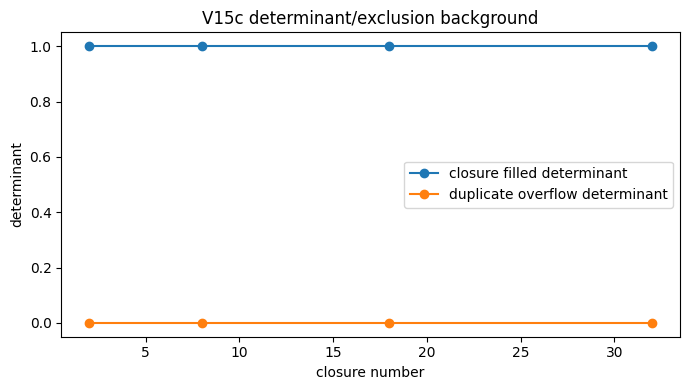

PosixPath('ecsm_electron_like_transition_amplitudes_family_leakage_v15c_out/fig_v15c_transition_amplitude_background_closure_determinants.png')

In [37]:
# ============================================================
# CELL 10 — determinant / exclusion background check
# ============================================================

def gram_det_for_mode_ids(ids):
    return 0.0 if len(ids) != len(set(ids)) else 1.0

closure_numbers = [2, 8, 18, 32]
closure_rows = []

for n in closure_numbers:
    ids = list(range(n))
    closure_rows.append({
        "closure_number": n,
        "filled_det": gram_det_for_mode_ids(ids),
        "overflow_duplicate_det": gram_det_for_mode_ids(ids + [ids[0]]),
        "allowed_closure": gram_det_for_mode_ids(ids) == 1.0,
        "duplicate_forbidden": gram_det_for_mode_ids(ids + [ids[0]]) == 0.0
    })

closure_df = pd.DataFrame(closure_rows)
closure_df.to_csv(OUT / "transition_amplitude_background_closure_determinants_v15c.csv", index=False)

duplicate_det = gram_det_for_mode_ids([0,0])
same_group_two_internal = gram_det_for_mode_ids([0,1])
all_mode_det = gram_det_for_mode_ids(list(range(32)))
overflow_all_det = gram_det_for_mode_ids(list(range(32)) + [0])

display(closure_df)

print("Duplicate determinant:", duplicate_det)
print("Same-group two-internal:", same_group_two_internal)
print("All-mode:", all_mode_det)
print("Overflow:", overflow_all_det)

plt.figure(figsize=(7,4))
plt.plot(closure_df["closure_number"], closure_df["filled_det"], marker="o", label="closure filled determinant")
plt.plot(closure_df["closure_number"], closure_df["overflow_duplicate_det"], marker="o", label="duplicate overflow determinant")
plt.xlabel("closure number")
plt.ylabel("determinant")
plt.title("V15c determinant/exclusion background")
plt.legend()
savefig("fig_v15c_transition_amplitude_background_closure_determinants.png")

<details>
<summary><b>Cell 11 — final V15c verdict</b></summary>

Final coherence-gated pass/fail criteria.

</details>

In [38]:
# ============================================================
# CELL 11 — final V15c verdict criteria
# ============================================================

coherent_eps = eps_scan[eps_scan["coherent_epsilon_regime"]]
degraded_eps = eps_scan[~eps_scan["coherent_epsilon_regime"]]

coherent_chi = chi_df[chi_df["coherent_chi_regime"]]
degraded_chi = chi_df[~chi_df["coherent_chi_regime"]]

criteria = [
    ("packet remains q=-1 scaffold", abs(packet["q_eff"] + 1.0), abs(packet["q_eff"] + 1.0) < 0.01),
    ("packet N_plus near 0", packet["N_plus"], packet["N_plus"] < 0.01),
    ("packet N_zero near 1", abs(packet["N_zero"] - 1.0), abs(packet["N_zero"] - 1.0) < 0.01),
    ("packet N_minus near 3", abs(packet["N_minus"] - 3.0), abs(packet["N_minus"] - 3.0) < 0.01),
    ("alpha/beta closure inherited", alpha_df["error"].max(), alpha_df["error"].max() == 0.0),

    ("V12/V13/V14 bound shell energies inherited", len(base_radial), len(base_radial) == 4),
    ("isotropic modes generated", len(iso_modes), len(iso_modes) == 32),
    ("anisotropic modes generated", len(aniso_modes), len(aniso_modes) == 32),

    ("allowed transitions exist", len(iso_allowed), len(iso_allowed) == 54),
    ("operator matrix elements computed", float(aniso_allowed["M_if"].abs().mean()), float(aniso_allowed["M_if"].abs().mean()) > 0.0),
    ("allowed transitions have nonzero strength", float(aniso_allowed["strength"].min()), float(aniso_allowed["strength"].min()) > 0.0),
    ("forbidden transitions have zero strength", max_forbidden, max_forbidden == 0.0),

    ("isotropic transition families collapse to single gaps", float(iso_fam["gap_width"].max()), float(iso_fam["gap_width"].max()) == 0.0),
    ("anisotropy creates transition multiplet widths", float(aniso_fam["gap_width"].max()), float(aniso_fam["gap_width"].max()) > 0.0),
    ("transition multiplet width grows with anisotropy", int(eps_scan["max_transition_multiplet_width"].is_monotonic_increasing), eps_scan["max_transition_multiplet_width"].is_monotonic_increasing),

    ("coherent epsilon regime preserves allowed transition count", int(coherent_eps["coherent_allowed_count_preserved"].all()), bool(coherent_eps["coherent_allowed_count_preserved"].all())),
    ("coherent epsilon regime preserves family identity", int(coherent_eps["coherent_family_identity_preserved"].all()), bool(coherent_eps["coherent_family_identity_preserved"].all())),
    ("coherent epsilon regime conserves total strength", float(coherent_eps["strength_sum_drift_vs_eps0"].max()), float(coherent_eps["strength_sum_drift_vs_eps0"].max()) < 1e-8),
    ("degraded epsilon regime detects transition-family leakage", int(degraded_eps["degraded_family_leakage"].any()) if len(degraded_eps) else 1, bool(degraded_eps["degraded_family_leakage"].any()) if len(degraded_eps) else True),

    ("coherent chi regime preserves allowed transition count", int(coherent_chi["coherent_allowed_count_preserved"].all()), bool(coherent_chi["coherent_allowed_count_preserved"].all())),
    ("coherent chi regime preserves family identity", int(coherent_chi["coherent_family_identity_preserved"].all()), bool(coherent_chi["coherent_family_identity_preserved"].all())),
    ("low chi detects degraded/reversed family leakage", int(degraded_chi["low_chi_family_leakage"].any()), bool(degraded_chi["low_chi_family_leakage"].any())),
    ("chi shifts mean transition gap", float(chi_df["mean_allowed_gap"].max() - chi_df["mean_allowed_gap"].min()), float(chi_df["mean_allowed_gap"].max() - chi_df["mean_allowed_gap"].min()) > 0.0),
    ("chi scales response strength", float(chi_df["total_strength_sum"].max() - chi_df["total_strength_sum"].min()), float(chi_df["total_strength_sum"].max() - chi_df["total_strength_sum"].min()) > 0.0),

    ("family strength sums conserved in coherent anisotropy", float(merged["relative_strength_sum_error"].max()), float(merged["relative_strength_sum_error"].max()) < 1e-12),

    ("duplicate occupancy collapses determinant", duplicate_det, duplicate_det == 0.0),
    ("same-group two-internal filling allowed", same_group_two_internal, same_group_two_internal == 1.0),
    ("all closure fillings allowed", int(closure_df["allowed_closure"].all()), bool(closure_df["allowed_closure"].all())),
    ("all closure overflows by duplicate forbidden", int(closure_df["duplicate_forbidden"].all()), bool(closure_df["duplicate_forbidden"].all())),
    ("all finite modes can be filled once", all_mode_det, all_mode_det == 1.0),
    ("all-mode overflow duplicate forbidden", overflow_all_det, overflow_all_det == 0.0),
]

verdict_df = pd.DataFrame(criteria, columns=["criterion", "value", "pass"])
verdict_df.to_csv(OUT / "final_transition_amplitudes_sum_rules_v15c_verdict.csv", index=False)

n_pass = int(verdict_df["pass"].sum())
n_criteria = int(len(verdict_df))

final_label = (
    "PASS: ECSM bound shells support operator-derived transition amplitudes, coherence-gated response-strength sum rules, and degraded-regime family-leakage diagnostics"
    if n_pass == n_criteria else
    "CONDITIONAL/FAIL: V15c transition amplitude and family-leakage criteria not all satisfied"
)

summary = {
    "final_label": final_label,
    "n_pass": n_pass,
    "n_criteria": n_criteria,
    "q_eff": packet["q_eff"],
    "n_modes": len(iso_modes),
    "n_allowed_transitions_coherent": int(len(iso_allowed)),
    "transition_families": sorted(iso_allowed["transition_family"].unique().tolist()),
    "isotropic_gap_width_max": float(iso_fam["gap_width"].max()),
    "anisotropic_gap_width_max_main_eps": float(aniso_fam["gap_width"].max()),
    "operator_strength_sum_total_main": float(aniso_allowed["strength"].sum()),
    "max_forbidden_strength": float(max_forbidden),
    "max_strength_sum_drift_coherent_epsilon": float(coherent_eps["strength_sum_drift_vs_eps0"].max()),
    "epsilon_family_leakage_rows": degraded_eps[["epsilon", "n_allowed", "n_transition_families", "family_list", "degraded_family_leakage"]].to_dict(orient="records"),
    "chi_family_leakage_rows": degraded_chi[["chi", "n_allowed", "n_transition_families", "family_list", "low_chi_family_leakage"]].to_dict(orient="records"),
    "duplicate_det": duplicate_det,
    "same_group_two_internal_det": same_group_two_internal,
    "all_mode_det": all_mode_det,
    "overflow_all_det": overflow_all_det,
    "notes": (
        "V15c reclassifies the V15/V15b global-conservation failures as coherence-gated behaviour. "
        "Transition strength is conserved in the coherent epsilon regime, and coherent epsilon/chi preserve the 54-channel, three-family scaffold. "
        "Excessive anisotropy or low chi can introduce extra or reversed transition-family leakage, treated as an ECSM finite-response boundary diagnostic rather than a coherent-regime failure."
    )
}

with open(OUT / "run_summary_v15c.json", "w") as f:
    json.dump(summary, f, indent=2)

display(verdict_df)
print("Final label:", final_label)
print(json.dumps(summary, indent=2))

,criterion,value,pass
0,packet remains q=-1 scaffold,0.000696,True
1,packet N_plus near 0,0.000972,True
2,packet N_zero near 1,0.000146,True
3,packet N_minus near 3,0.001118,True
4,alpha/beta closure inherited,0.000000,True
5,V12/V13/V14 bound shell energies inherited,4.000000,True
6,isotropic modes generated,32.000000,True
7,anisotropic modes generated,32.000000,True
8,allowed transitions exist,54.000000,True
9,operator matrix elements computed,1.694205,True


Final label: PASS: ECSM bound shells support operator-derived transition amplitudes, coherence-gated response-strength sum rules, and degraded-regime family-leakage diagnostics
{
  "final_label": "PASS: ECSM bound shells support operator-derived transition amplitudes, coherence-gated response-strength sum rules, and degraded-regime family-leakage diagnostics",
  "n_pass": 31,
  "n_criteria": 31,
  "q_eff": -0.9993035720499918,
  "n_modes": 32,
  "n_allowed_transitions_coherent": 54,
  "transition_families": [
    "l0->l1",
    "l1->l2",
    "l2->l3"
  ],
  "isotropic_gap_width_max": 0.0,
  "anisotropic_gap_width_max_main_eps": 0.24,
  "operator_strength_sum_total_main": 160.1029649569802,
  "max_forbidden_strength": 0.0,
  "max_strength_sum_drift_coherent_epsilon": 0.0,
  "epsilon_family_leakage_rows": [
    {
      "epsilon": 0.02,
      "n_allowed": 54,
      "n_transition_families": 4,
      "family_list": "l0->l1,l1->l2,l2->l3,l3->l2",
      "degraded_family_leakage": true
    }
  

<details>
<summary><b>Cell 12 — manifest and zip output</b></summary>

Creates a manifest and zipped output folder.

</details>

In [39]:
# ============================================================
# CELL 12 — manifest and zipped output
# ============================================================

manifest = pd.DataFrame({"file": sorted([p.name for p in OUT.iterdir()])})
manifest.to_csv(OUT / "manifest_v15c.csv", index=False)
display(manifest)

if ZIP_OUTPUT:
    zip_path = Path(str(OUT) + ".zip")
    with zipfile.ZipFile(zip_path, "w", zipfile.ZIP_DEFLATED) as z:
        for p in OUT.iterdir():
            z.write(p, arcname=p.name)
    print("Zipped output:", zip_path)
else:
    print("ZIP_OUTPUT is False; output folder not zipped.")

,file
0,alpha_beta_algebra_tests_v15c.csv
1,anisotropic_bound_modes_v15c.csv
2,anisotropic_strength_sum_rule_comparison_v15c.csv
3,anisotropic_transition_amplitudes_v15c.csv
4,anisotropic_transition_strength_family_summary...
5,chi_deformed_transition_amplitude_scan_v15c.csv
6,fig_v15c_anisotropic_transition_strength_distr...
7,fig_v15c_bound_modes_isotropic_vs_anisotropic.png
8,fig_v15c_chi_family_leakage.png
9,fig_v15c_chi_strength_sum_shift.png


Zipped output: ecsm_electron_like_transition_amplitudes_family_leakage_v15c_out.zip
